# Customer Segmentation with K-Means

**Objective**
- Perform customer segmentation on the mall dataset using K-Means clustering.
- Identify meaningful customer groups based on annual income and spending score.
- Summarize the business meaning of each cluster in plain language.


## Approach

We will:
1. Load the mall customer dataset.
2. Explore the data and select the two features most commonly used for segmentation: **Annual Income (k$)** and **Spending Score (1-100)**.
3. Use the elbow method to choose a suitable number of clusters.
4. Train a K-Means model and visualize the resulting customer groups.
5. Describe each customer segment based on its centroid and cluster size.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

from IPython.display import display


In [2]:
DATA_URL = 'https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv'
DATA_DIR = Path('data')
LOCAL_FILE = DATA_DIR / 'Mall_Customers.csv'

if LOCAL_FILE.exists():
    df = pd.read_csv(LOCAL_FILE)
    data_source = f'local file: {LOCAL_FILE}'
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(DATA_URL)
    df.to_csv(LOCAL_FILE, index=False)
    data_source = f'downloaded from: {DATA_URL}'

print(f'Dataset loaded from {data_source}')
print(f'Shape: {df.shape}')
df.head()


Dataset loaded from downloaded from: https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


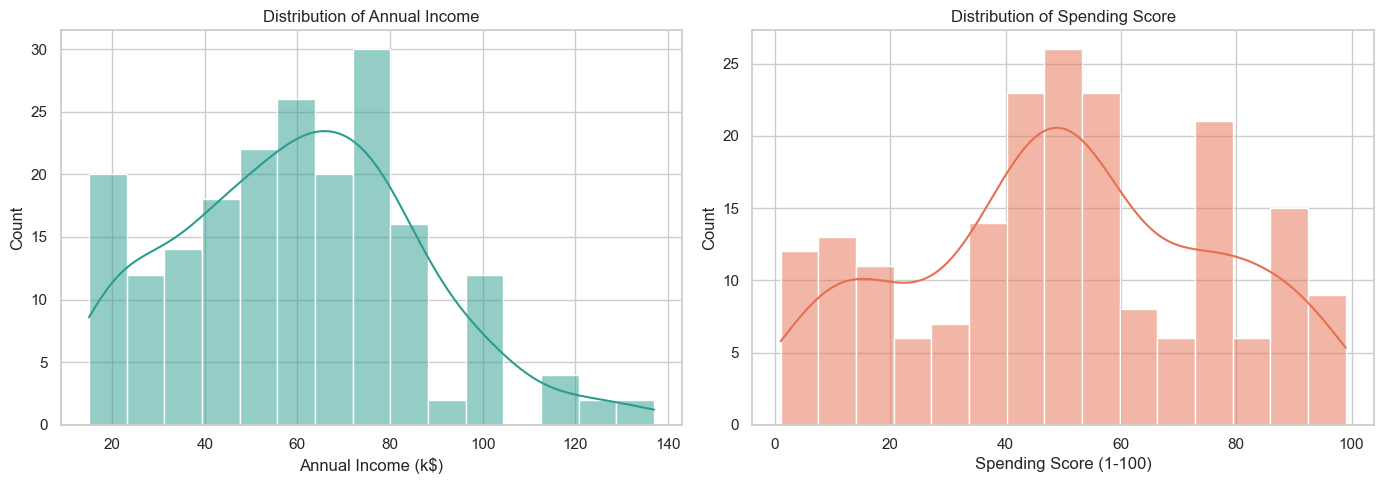

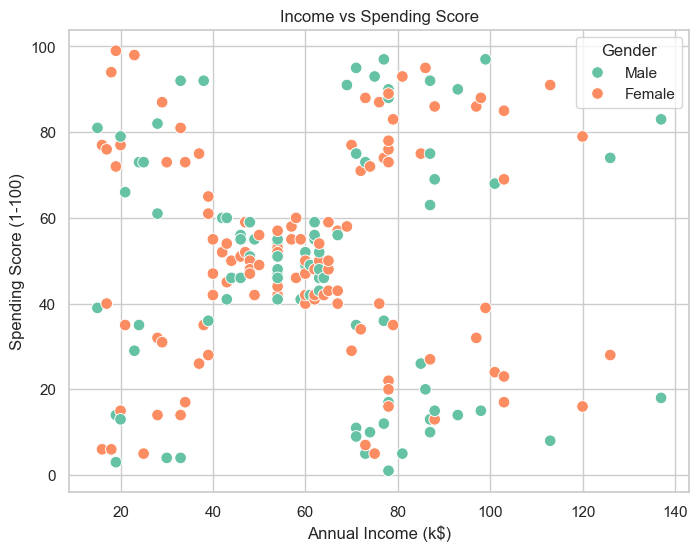

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Annual Income (k$)'], bins=15, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Distribution of Annual Income')

sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True, ax=axes[1], color='#e76f51')
axes[1].set_title('Distribution of Spending Score')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    palette='Set2',
    s=70,
)
plt.title('Income vs Spending Score')
plt.show()


## Feature Selection

For mall customer segmentation, the most interpretable 2D segmentation usually uses:
- **Annual Income (k$)**
- **Spending Score (1-100)**

These features directly separate customers by purchasing power and spending behavior.


In [6]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()
X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


  File "C:\Users\jaypr\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\jaypr\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jaypr\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\jaypr\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


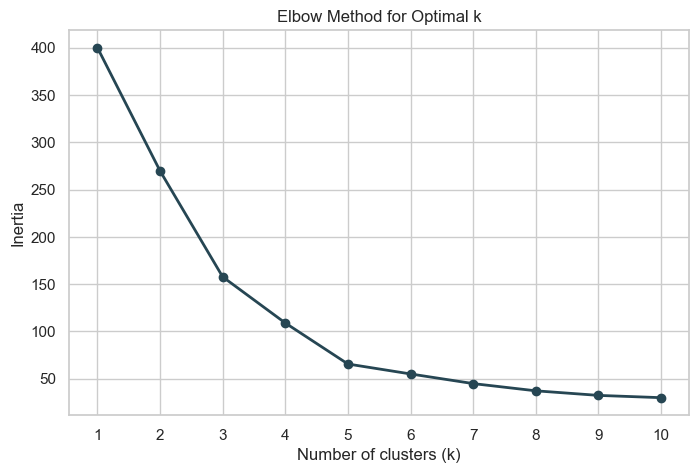

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker='o', linewidth=2, color='#264653')
plt.xticks(list(k_values))
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


## K-Means Clustering

The elbow curve typically shows a visible bend around **k = 5**, which is also a well-known good fit for this dataset. We will use **5 clusters** for the final segmentation.


In [8]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centroid_df = pd.DataFrame(centers, columns=features)
centroid_df.index.name = 'Cluster'
centroid_df


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


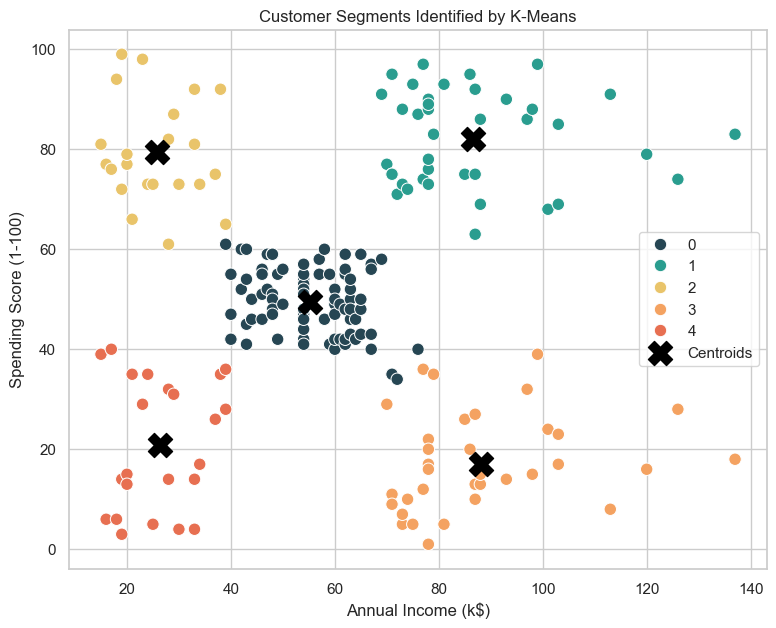

In [9]:
plt.figure(figsize=(9, 7))
palette = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette=palette,
    s=80,
)

plt.scatter(
    centroid_df['Annual Income (k$)'],
    centroid_df['Spending Score (1-100)'],
    s=300,
    c='black',
    marker='X',
    label='Centroids',
)

plt.title('Customer Segments Identified by K-Means')
plt.legend()
plt.show()


In [10]:
cluster_summary = (
    df.groupby('Cluster')
      .agg(
          customers=('CustomerID', 'count'),
          avg_age=('Age', 'mean'),
          avg_income=('Annual Income (k$)', 'mean'),
          avg_spending_score=('Spending Score (1-100)', 'mean')
      )
      .round(2)
      .sort_values(by=['avg_income', 'avg_spending_score'])
)

cluster_summary


,customers,avg_age,avg_income,avg_spending_score
Cluster,,,,
2,22,25.27,25.73,79.36
4,23,45.22,26.30,20.91
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
3,35,41.11,88.20,17.11


In [11]:
def describe_cluster(row):
    income = row['avg_income']
    spending = row['avg_spending_score']

    if income < 45 and spending < 40:
        return 'Budget-conscious customers: lower income and lower spending.'
    if income < 45 and spending >= 60:
        return 'High-engagement value shoppers: lower income but high spending.'
    if income >= 70 and spending < 40:
        return 'Careful affluent customers: high income but conservative spending.'
    if income >= 70 and spending >= 60:
        return 'Premium customers: high income and high spending.'
    return 'Mainstream customers: moderate income and moderate spending.'

segment_report = cluster_summary.copy()
segment_report['segment_description'] = segment_report.apply(describe_cluster, axis=1)
segment_report


,customers,avg_age,avg_income,avg_spending_score,segment_description
Cluster,,,,,
2,22,25.27,25.73,79.36,High-engagement value shoppers: lower income b...
4,23,45.22,26.30,20.91,Budget-conscious customers: lower income and l...
0,81,42.72,55.30,49.52,Mainstream customers: moderate income and mode...
1,39,32.69,86.54,82.13,Premium customers: high income and high spending.
3,35,41.11,88.20,17.11,Careful affluent customers: high income but co...


## Interpretation of Customer Groups

The segments generally map to these business-friendly groups:
- **Budget-conscious customers**: lower income and lower spending. These customers may respond to discounts and essentials-focused offers.
- **High-engagement value shoppers**: lower income but high spending. They are active buyers despite limited income and may respond well to loyalty programs.
- **Mainstream customers**: mid-range income and moderate spending. They represent a stable core customer base.
- **Careful affluent customers**: higher income but lower spending. They have capacity to spend more, but need stronger value propositions.
- **Premium customers**: high income and high spending. These are the most valuable customers for premium campaigns and exclusive promotions.


In [12]:
print('Final cluster summary:')
display(segment_report)


Final cluster summary:


,customers,avg_age,avg_income,avg_spending_score,segment_description
Cluster,,,,,
2,22,25.27,25.73,79.36,High-engagement value shoppers: lower income b...
4,23,45.22,26.30,20.91,Budget-conscious customers: lower income and l...
0,81,42.72,55.30,49.52,Mainstream customers: moderate income and mode...
1,39,32.69,86.54,82.13,Premium customers: high income and high spending.
3,35,41.11,88.20,17.11,Careful affluent customers: high income but co...


## Conclusion

K-Means clustering successfully separates mall customers into **five distinct groups** using annual income and spending score.

This segmentation can help the business:
- target premium customers with exclusive offers,
- retain high-spending lower-income shoppers with loyalty incentives,
- grow cautious affluent customers through personalized campaigns,
- and support mainstream or budget-conscious segments with value-driven messaging.

Overall, the model provides a simple and useful foundation for customer-focused marketing decisions.
